# Reading Recommendation System

## Goal

The task is to recommend what a user should read next from their reading history.

I frame this as a **book-level recommendation** problem. The raw data is at chapter level, but the interaction patterns show that a pure next-chapter system is not well supported here. Almost every user-book pair has only one chapter interaction, so there is very little real within-book progression to model.

The main design choice is simple: **do not treat every user profile with equal confidence**.

A user with 1–3 interactions should not be personalized as aggressively as someone with 8+ interactions. So the model first segments users by activity level, then changes the recommendation strategy by segment.


## Problem framing

Before modeling, I considered three possible versions of the task:

| Direction | Decision | Reason |
|---|---:|---|
| Recommend next chapter within a book | Rejected | Only a tiny share of user-book pairs have more than one chapter interaction |
| Build a sequential model | Rejected | No timestamps, so interaction order and recency are unknown |
| Recommend the next book to start | Chosen | Book-level data is much less sparse and matches the observed interaction pattern |

So the final task is:

> Given a user's past book interactions, rank unread books that they may want to read next.

I treat each `(user_id, book_id)` pair as implicit positive feedback. There are no explicit ratings, likes, dwell time, or completion labels, so the model should stay conservative about what it claims.


## Important assumptions and scope choices

The data does not include timestamps, ratings, likes, dislikes, dwell time, or completion events.

So I make a few practical assumptions:

- each interaction is treated as implicit positive feedback,
- popularity means “relatively more interacted with in this sparse catalog”, not “most users have read it”,
- a late chapter interaction is not proof of completion,
- chapter depth is useful to inspect but not reliable enough for the final score,
- evaluation uses a user-level random holdout because chronological splitting is impossible without timestamps,
- tags are used as lightweight affinity signals, not as strong semantic features.

I also made two explicit scope choices:

- I did not do deep chapter-wise content/category analysis of tags. Tags are used as provided, mainly to add category skew and interpretability.
- I did not use `published_date` in the final recommender. Without interaction timestamps, I can tell whether a book/chapter is older or newer, but I cannot honestly infer what is currently trending.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 1. Load data

In [2]:
DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")

chapters = pd.read_csv(DATA_DIR / "chapters.csv")
interactions = pd.read_csv(DATA_DIR / "interactions.csv")

print("chapters:", chapters.shape)
print("interactions:", interactions.shape)

display(chapters.head())
display(interactions.head())

chapters: (50000, 6)
interactions: (1000000, 3)


,chapter_id,chapter_sequence_no,book_id,author_id,published_date,tags
0,2812946,1,139726,66847,1990-03-22,Fantasy|Horror
1,4330764,2,139726,66847,1990-04-09,Fantasy|Young Adult|Literary Fiction
2,2664499,3,139726,66847,1990-04-07,Fantasy
3,2260666,4,139726,66847,1990-05-18,Literary Fiction|Fantasy
4,6069976,1,191772,62262,2008-07-30,Horror|Young Adult|Romance|Graphic Novel


,user_id,chapter_id,book_id
0,user_2378720,5894067,444295
1,user_2321122,2532511,785684
2,user_2335775,6777764,999595
3,user_7906001,7366896,748410
4,user_9981689,7853186,418083


In [3]:
print("Chapter columns:", chapters.columns.tolist())
print("Interaction columns:", interactions.columns.tolist())

print("\nMissing values in chapters:")
display(chapters.isna().sum())

print("\nMissing values in interactions:")
display(interactions.isna().sum())

data_summary = {
    "unique_users": interactions["user_id"].nunique(),
    "unique_books": interactions["book_id"].nunique(),
    "unique_chapters_in_interactions": interactions["chapter_id"].nunique(),
    "chapters_in_metadata": chapters["chapter_id"].nunique(),
    "unique_authors": chapters["author_id"].nunique(),
}

display(pd.Series(data_summary, name="count"))

Chapter columns: ['chapter_id', 'chapter_sequence_no', 'book_id', 'author_id', 'published_date', 'tags']
Interaction columns: ['user_id', 'chapter_id', 'book_id']

Missing values in chapters:


chapter_id             0
chapter_sequence_no    0
book_id                0
author_id              0
published_date         0
tags                   0
dtype: int64


Missing values in interactions:


user_id       0
chapter_id    0
book_id       0
dtype: int64

unique_users                       149803
unique_books                         9575
unique_chapters_in_interactions     49998
chapters_in_metadata                50000
unique_authors                       4263
Name: count, dtype: int64

## Data characterization: what the dataset actually supports

Before choosing the model, I looked for the strongest usable signals.

A few things stood out:

1. **User histories are short and capped.** Users have between 1 and 20 interactions, with the median around 6. This looks artificially capped or sampled, not like full organic reading history.
2. **Sequential reading is almost absent.** The assignment mentions chapter progression, but nearly every user-book pair has only one chapter interaction.
3. **There are no timestamps.** So I cannot model recency, session order, or “recently trending” content.
4. **Genre tags are fairly uniform.** Tags can still help as lightweight affinity signals, but I should not overclaim that genre overlap is a strong content model.

This is why I choose a simple, explainable book-level recommender rather than a complex sequence model.


In [4]:
# Direct check: how often does a user read more than one chapter from the same book?
user_book_depth_check = (
    interactions
    .groupby(["user_id", "book_id"])["chapter_id"]
    .nunique()
    .reset_index(name="chapters_read")
)

multi_chapter_check = user_book_depth_check[user_book_depth_check["chapters_read"] > 1]

print(f"Total user-book pairs:      {len(user_book_depth_check):>10,}")
print(
    f"Pairs with >1 chapter read: {len(multi_chapter_check):>10,} "
    f"({len(multi_chapter_check) / len(user_book_depth_check) * 100:.2f}%)"
)
print()
print("chapters_read breakdown:")
print(multi_chapter_check["chapters_read"].value_counts().sort_index())


Total user-book pairs:         999,520
Pairs with >1 chapter read:        480 (0.05%)

chapters_read breakdown:
chapters_read
2    480
Name: count, dtype: int64


## 2. User interaction frequency distribution

count    149803.000000
mean          6.675434
std           2.572317
min           1.000000
25%           5.000000
50%           6.000000
75%           8.000000
max          20.000000
Name: total_interactions, dtype: float64

,total_interactions,num_users,user_share,cumulative_user_share
0,1,1254,0.008371,0.008371
1,2,4265,0.028471,0.036842
2,3,9334,0.062308,0.099150
3,4,15808,0.105525,0.204675
4,5,20736,0.138422,0.343097
5,6,23575,0.157373,0.500471
6,7,22243,0.148482,0.648952
7,8,18322,0.122307,0.771260
8,9,13771,0.091927,0.863187
9,10,9013,0.060166,0.923353


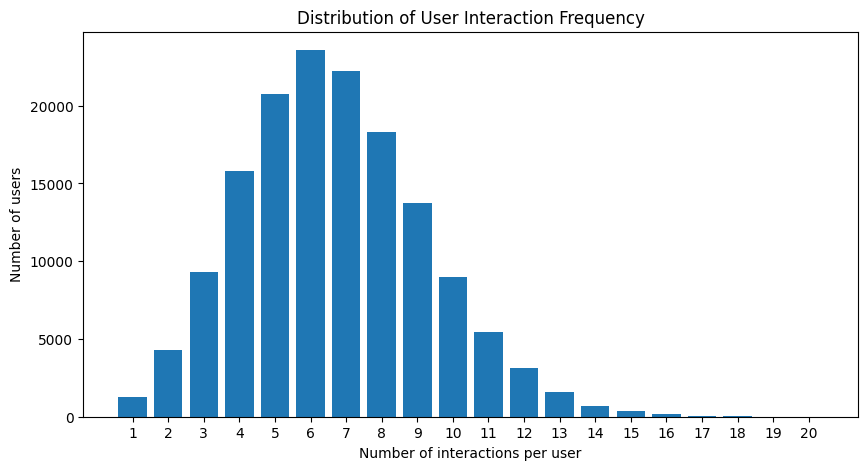

In [5]:
user_interaction_freq = (
    interactions
    .groupby("user_id")
    .size()
    .reset_index(name="total_interactions")
)

display(user_interaction_freq["total_interactions"].describe())

interaction_distribution = (
    user_interaction_freq["total_interactions"]
    .value_counts()
    .sort_index()
    .reset_index()
)

interaction_distribution.columns = ["total_interactions", "num_users"]
interaction_distribution["user_share"] = interaction_distribution["num_users"] / interaction_distribution["num_users"].sum()
interaction_distribution["cumulative_user_share"] = interaction_distribution["user_share"].cumsum()

display(interaction_distribution)

plt.figure(figsize=(10, 5))
plt.bar(interaction_distribution["total_interactions"], interaction_distribution["num_users"])
plt.xlabel("Number of interactions per user")
plt.ylabel("Number of users")
plt.title("Distribution of User Interaction Frequency")
plt.xticks(interaction_distribution["total_interactions"])
plt.show()

,activity_segment,num_users,user_share
0,early_reader,14853,0.099150
1,developing_reader,82362,0.549802
2,committed_reader,52588,0.351048


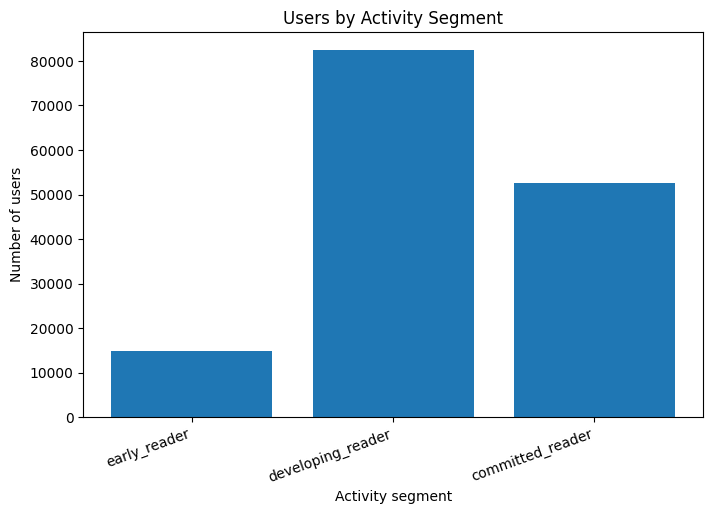

In [6]:
def assign_activity_from_count(n):
    if n <= 3:
        return "early_reader"
    if n <= 7:
        return "developing_reader"
    return "committed_reader"

user_interaction_freq["activity_segment"] = user_interaction_freq["total_interactions"].apply(assign_activity_from_count)

activity_distribution = (
    user_interaction_freq["activity_segment"]
    .value_counts()
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

activity_distribution.columns = ["activity_segment", "num_users"]
activity_distribution["user_share"] = activity_distribution["num_users"] / activity_distribution["num_users"].sum()

display(activity_distribution)

plt.figure(figsize=(8, 5))
plt.bar(activity_distribution["activity_segment"], activity_distribution["num_users"])
plt.xlabel("Activity segment")
plt.ylabel("Number of users")
plt.title("Users by Activity Segment")
plt.xticks(rotation=20, ha="right")
plt.show()

### Takeaway

This distribution is why I use activity segmentation. The median user has around 6 interactions, but the difference between 2–3 interactions and 8+ interactions matters a lot.

So frequency becomes the first-level feature:

- early readers: 1–3 interactions,
- developing readers: 4–7 interactions,
- committed readers: 8+ interactions.

Taste and similarity still matter, but only after accounting for how much user history we can actually trust.

## 3. Chapter tags and book metadata

In [7]:
chapter_tags = (
    chapters[["chapter_id", "book_id", "tags"]]
    .assign(tag=lambda df: df["tags"].astype(str).str.split("|"))
    .explode("tag")
)

chapter_tags["tag"] = chapter_tags["tag"].str.strip()

all_tags = sorted(chapter_tags["tag"].unique())
print("Unique tags:", len(all_tags))
print(all_tags)

Unique tags: 15
['Adventure', 'Crime', 'Dystopian', 'Fantasy', 'Graphic Novel', 'Historical Fiction', 'Horror', 'Humor', 'Literary Fiction', 'Mystery', 'Paranormal', 'Romance', 'Science Fiction', 'Thriller', 'Young Adult']


### Global tag distribution

I also check the raw tag distribution. The tags are useful for category skew, but the distribution is quite balanced, so I treat them as **lightweight affinity signals**, not as the main model.


In [8]:
tag_distribution = (
    chapter_tags["tag"]
    .value_counts()
    .rename_axis("tag")
    .reset_index(name="chapter_tag_count")
)

tag_distribution["share"] = tag_distribution["chapter_tag_count"] / tag_distribution["chapter_tag_count"].sum()

display(tag_distribution)
print("Tag count range:", tag_distribution["chapter_tag_count"].min(), "to", tag_distribution["chapter_tag_count"].max())


,tag,chapter_tag_count,share
0,Crime,8589,0.068608
1,Historical Fiction,8547,0.068272
2,Dystopian,8448,0.067481
3,Adventure,8445,0.067457
4,Young Adult,8393,0.067042
5,Romance,8389,0.067010
6,Science Fiction,8387,0.066994
7,Graphic Novel,8376,0.066906
8,Paranormal,8359,0.066771
9,Literary Fiction,8325,0.066499


Tag count range: 8039 to 8589


In [9]:
book_meta = (
    chapters
    .groupby("book_id")
    .agg(
        total_chapters=("chapter_id", "nunique"),
        author_id=("author_id", "first"),
        first_published_date=("published_date", "min")
    )
    .reset_index()
)

book_tag_profile_df = (
    chapter_tags
    .groupby(["book_id", "tag"])
    .size()
    .reset_index(name="tag_count")
)

book_tag_profile_df["total_tag_count"] = book_tag_profile_df.groupby("book_id")["tag_count"].transform("sum")
book_tag_profile_df["book_tag_score"] = book_tag_profile_df["tag_count"] / book_tag_profile_df["total_tag_count"]

dominant_book_tag = (
    book_tag_profile_df
    .sort_values(["book_id", "book_tag_score"], ascending=[True, False])
    .drop_duplicates("book_id")
    [["book_id", "tag", "book_tag_score"]]
    .rename(columns={"tag": "dominant_tag", "book_tag_score": "dominant_tag_share"})
)

book_meta = book_meta.merge(dominant_book_tag, on="book_id", how="left")

display(book_meta.head())
display(book_meta["total_chapters"].describe())

,book_id,total_chapters,author_id,first_published_date,dominant_tag,dominant_tag_share
0,100089,3,55121,1995-03-24,Fantasy,0.750000
1,100096,1,61876,2015-12-31,Romance,1.000000
2,100193,4,67983,1996-01-26,Thriller,0.307692
3,100205,4,64099,2016-02-26,Adventure,0.363636
4,100301,3,77538,2015-08-14,Humor,0.600000


count    9575.000000
mean        5.221932
std         4.056853
min         1.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        20.000000
Name: total_chapters, dtype: float64

## 4. User-book interaction table

In [10]:
interactions_with_chapters = interactions.merge(
    chapters[["chapter_id", "book_id", "chapter_sequence_no", "author_id"]],
    on=["chapter_id", "book_id"],
    how="left"
).merge(
    book_meta[["book_id", "total_chapters"]],
    on="book_id",
    how="left"
)

interactions_with_chapters["chapter_depth_ratio"] = (
    interactions_with_chapters["chapter_sequence_no"] / interactions_with_chapters["total_chapters"]
)

user_book = (
    interactions_with_chapters
    .groupby(["user_id", "book_id"])
    .agg(
        interaction_count=("chapter_id", "size"),
        distinct_chapters=("chapter_id", "nunique"),
        max_chapter_sequence=("chapter_sequence_no", "max"),
        min_chapter_sequence=("chapter_sequence_no", "min"),
        avg_chapter_depth=("chapter_depth_ratio", "mean"),
        max_chapter_depth=("chapter_depth_ratio", "max"),
        author_id=("author_id", "first"),
        total_chapters=("total_chapters", "first")
    )
    .reset_index()
)

user_book["coverage_ratio"] = user_book["distinct_chapters"] / user_book["total_chapters"]

# Final model uses interaction frequency as implicit feedback.
# Chapter depth is kept for EDA, but not used in scoring.
user_book["engagement_weight"] = np.log1p(user_book["interaction_count"])

display(user_book.head())
display(user_book[[
    "interaction_count",
    "distinct_chapters",
    "avg_chapter_depth",
    "max_chapter_depth",
    "coverage_ratio",
    "engagement_weight"
]].describe())

,user_id,book_id,interaction_count,distinct_chapters,max_chapter_sequence,min_chapter_sequence,avg_chapter_depth,max_chapter_depth,author_id,total_chapters,coverage_ratio,engagement_weight
0,user_0000013,200976,1,1,5,5,0.625000,0.625000,97819,8,0.125000,0.693147
1,user_0000013,461083,1,1,1,1,0.125000,0.125000,34356,8,0.125000,0.693147
2,user_0000013,469844,1,1,2,2,1.000000,1.000000,52899,2,0.500000,0.693147
3,user_0000013,635456,1,1,7,7,0.875000,0.875000,46822,8,0.125000,0.693147
4,user_0000013,878246,1,1,1,1,0.111111,0.111111,22675,9,0.111111,0.693147


,interaction_count,distinct_chapters,avg_chapter_depth,max_chapter_depth,coverage_ratio,engagement_weight
count,999520.000000,999520.000000,999520.000000,999520.000000,999520.000000,999520.000000
mean,1.000480,1.000480,0.595739,0.595830,0.192802,0.693342
std,0.021909,0.021909,0.288454,0.288478,0.161164,0.008883
min,1.000000,1.000000,0.050000,0.050000,0.050000,0.693147
25%,1.000000,1.000000,0.333333,0.333333,0.083333,0.693147
50%,1.000000,1.000000,0.600000,0.600000,0.142857,0.693147
75%,1.000000,1.000000,0.833333,0.833333,0.250000,0.693147
max,2.000000,2.000000,1.000000,1.000000,1.000000,1.098612


## 5. Check how much chapter progression signal exists

In [13]:
progression_summary = {
    "total_interactions": len(interactions),
    "unique_user_book_pairs": len(user_book),
    "pairs_with_multiple_interactions": int((user_book["interaction_count"] > 1).sum()),
    "pairs_with_multiple_distinct_chapters": int((user_book["distinct_chapters"] > 1).sum()),
    "share_pairs_multiple_interactions": float((user_book["interaction_count"] > 1).mean()),
    "share_pairs_multiple_distinct_chapters": float((user_book["distinct_chapters"] > 1).mean()),
}

display(pd.Series(progression_summary))
display(user_book["interaction_count"].value_counts().head(10).rename("user_book_pair_count").to_frame())

total_interactions                        1000000.00000
unique_user_book_pairs                     999520.00000
pairs_with_multiple_interactions              480.00000
pairs_with_multiple_distinct_chapters         480.00000
share_pairs_multiple_interactions               0.00048
share_pairs_multiple_distinct_chapters          0.00048
dtype: float64

,user_book_pair_count
interaction_count,
1,999040
2,480


### Takeaway

Repeated user-book progression is almost absent. Only a tiny fraction of user-book pairs have more than one chapter interaction.

So I do not build a pure next-chapter recommender. I keep the recommendation task at book level and use chapter/order fields only for exploratory checks.

## Train/test split: per-user leave-one-out

There are no timestamps, so a temporal split is not possible.

I use a per-user leave-one-out setup: for each eligible user, I hold out one book interaction as the test item and train on the rest. The model must rank the held-out book in the top-k recommendations.

I include users with at least two interacted books, so every evaluated user has at least one training item and one held-out item. This lets me separately inspect low-history users instead of hiding them inside the aggregate metric.


In [14]:
eligible_users = (
    user_book
    .groupby("user_id")["book_id"]
    .nunique()
    .reset_index(name="books_read")
)

# Need at least one training book and one held-out book.
eligible_users = eligible_users[eligible_users["books_read"] >= 2]["user_id"]
eval_user_book = user_book[user_book["user_id"].isin(eligible_users)].copy()

test_rows = []
for user_id, group in eval_user_book.groupby("user_id"):
    test_rows.append(rng.choice(group.index.to_numpy(), size=1)[0])

test_idx = set(test_rows)

test_user_book = eval_user_book.loc[list(test_idx)].copy()
train_user_book = eval_user_book.drop(index=list(test_idx)).copy()

print("Eligible users:", eval_user_book["user_id"].nunique())
print("Train rows:", train_user_book.shape)
print("Test rows:", test_user_book.shape)
print("Unique test users:", test_user_book["user_id"].nunique())


Eligible users: 148548
Train rows: (849717, 12)
Test rows: (148548, 12)
Unique test users: 148548


From here onward, user features are built from the **training split only**. This avoids using the held-out book while profiling users.

This matters because otherwise the model would accidentally know part of the answer during evaluation.


## 7. Train-only user activity segments

In [15]:
train_user_activity = (
    train_user_book
    .groupby("user_id")
    .agg(
        train_total_interactions=("interaction_count", "sum"),
        train_books_read=("book_id", "nunique"),
        train_total_engagement=("engagement_weight", "sum"),
        avg_depth=("max_chapter_depth", "mean"),
        median_depth=("max_chapter_depth", "median"),
        late_depth_book_count=("max_chapter_depth", lambda x: int((x >= 0.75).sum())),
        max_depth=("max_chapter_depth", "max")
    )
    .reset_index()
)

def assign_activity_segment(row):
    if row["train_total_interactions"] <= 3:
        return "early_reader"
    if row["train_total_interactions"] <= 7:
        return "developing_reader"
    return "committed_reader"

train_user_activity["activity_segment"] = train_user_activity.apply(assign_activity_segment, axis=1)

activity_segment_counts = (
    train_user_activity["activity_segment"]
    .value_counts()
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

activity_segment_counts.columns = ["activity_segment", "users"]
activity_segment_counts["share"] = activity_segment_counts["users"] / activity_segment_counts["users"].sum()

display(activity_segment_counts)
display(train_user_activity.head())

,activity_segment,users,share
0,early_reader,29411,0.197990
1,developing_reader,84889,0.571458
2,committed_reader,34248,0.230552


,user_id,train_total_interactions,train_books_read,train_total_engagement,avg_depth,median_depth,late_depth_book_count,max_depth,activity_segment
0,user_0000013,6,6,4.158883,0.534858,0.549020,3,1.000000,developing_reader
1,user_0000115,5,5,3.465736,0.552222,0.600000,1,0.800000,developing_reader
2,user_0000177,5,5,3.465736,0.461558,0.500000,0,0.636364,developing_reader
3,user_0000188,7,7,4.852030,0.569161,0.500000,2,1.000000,developing_reader
4,user_0000257,4,4,2.772589,0.630952,0.595238,2,1.000000,developing_reader


## 8. Tag/category mix by user activity segment

In [16]:
train_pairs = train_user_book[["user_id", "book_id"]].copy()
train_pairs["is_train"] = 1

train_interactions = interactions.merge(train_pairs, on=["user_id", "book_id"], how="inner")

train_interaction_tags = train_interactions.merge(
    chapter_tags[["chapter_id", "book_id", "tag"]],
    on=["chapter_id", "book_id"],
    how="left"
)

train_interaction_tags = train_interaction_tags.merge(
    train_user_activity[["user_id", "activity_segment"]],
    on="user_id",
    how="left"
)

segment_tag_mix = (
    train_interaction_tags
    .groupby(["activity_segment", "tag"])
    .size()
    .reset_index(name="tag_interactions")
)

segment_tag_mix["segment_total"] = segment_tag_mix.groupby("activity_segment")["tag_interactions"].transform("sum")
segment_tag_mix["tag_share_within_segment"] = segment_tag_mix["tag_interactions"] / segment_tag_mix["segment_total"]

display(
    segment_tag_mix
    .sort_values(["activity_segment", "tag_share_within_segment"], ascending=[True, False])
    .groupby("activity_segment")
    .head(8)
)

,activity_segment,tag,tag_interactions,segment_total,tag_share_within_segment
14,committed_reader,Young Adult,54668,794005,0.068851
1,committed_reader,Crime,53879,794005,0.067857
5,committed_reader,Historical Fiction,53722,794005,0.067660
13,committed_reader,Thriller,53610,794005,0.067518
2,committed_reader,Dystopian,53557,794005,0.067452
6,committed_reader,Horror,53303,794005,0.067132
4,committed_reader,Graphic Novel,53249,794005,0.067064
11,committed_reader,Romance,53214,794005,0.067020
29,developing_reader,Young Adult,80148,1160228,0.069080
20,developing_reader,Historical Fiction,78936,1160228,0.068035


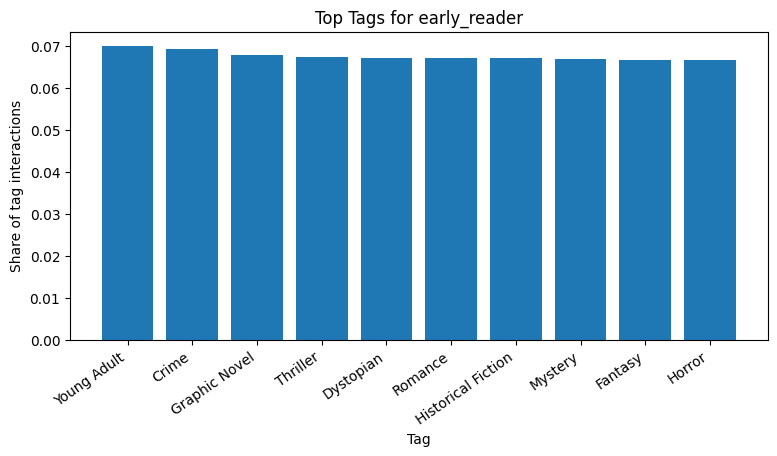

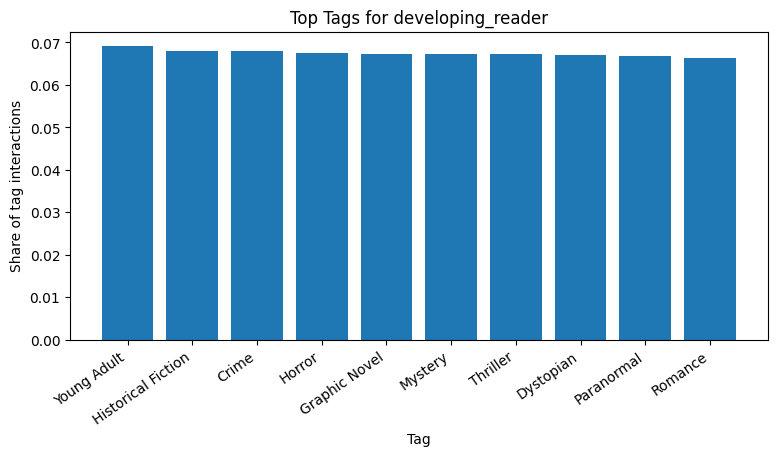

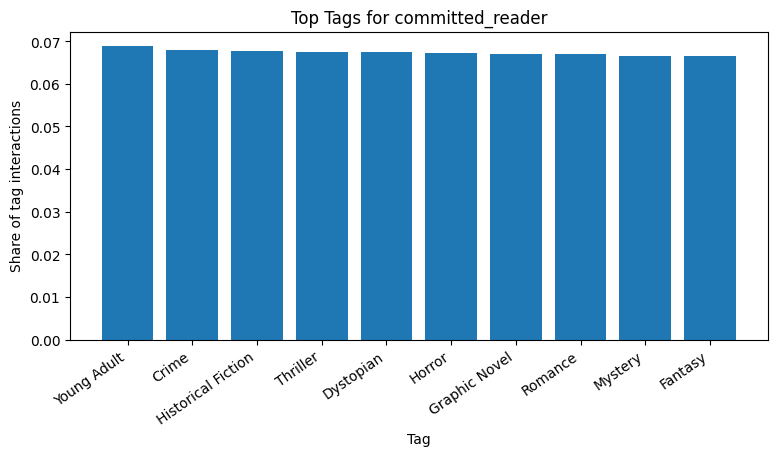

In [17]:
for segment in ["early_reader", "developing_reader", "committed_reader"]:
    plot_df = (
        segment_tag_mix[segment_tag_mix["activity_segment"] == segment]
        .sort_values("tag_share_within_segment", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(9, 4))
    plt.bar(plot_df["tag"], plot_df["tag_share_within_segment"])
    plt.title(f"Top Tags for {segment}")
    plt.xlabel("Tag")
    plt.ylabel("Share of tag interactions")
    plt.xticks(rotation=35, ha="right")
    plt.show()

## 9. Depth distribution by user activity segment

In [18]:
depth_summary_by_segment = (
    train_user_activity
    .groupby("activity_segment")
    .agg(
        users=("user_id", "count"),
        avg_depth_mean=("avg_depth", "mean"),
        avg_depth_median=("avg_depth", "median"),
        late_depth_books_mean=("late_depth_book_count", "mean"),
        train_interactions_mean=("train_total_interactions", "mean"),
        train_interactions_median=("train_total_interactions", "median")
    )
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

display(depth_summary_by_segment)

,activity_segment,users,avg_depth_mean,avg_depth_median,late_depth_books_mean,train_interactions_mean,train_interactions_median
0,early_reader,29411,0.595349,0.598793,0.870899,2.392438,3.0
1,developing_reader,84889,0.595684,0.596062,1.982130,5.449564,5.0
2,committed_reader,34248,0.595827,0.595679,3.372343,9.260336,9.0


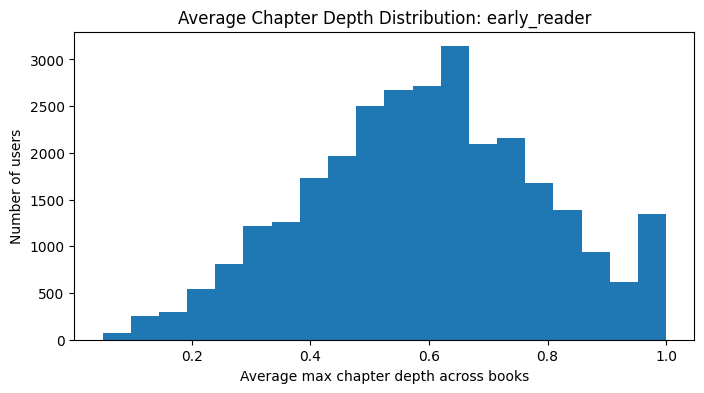

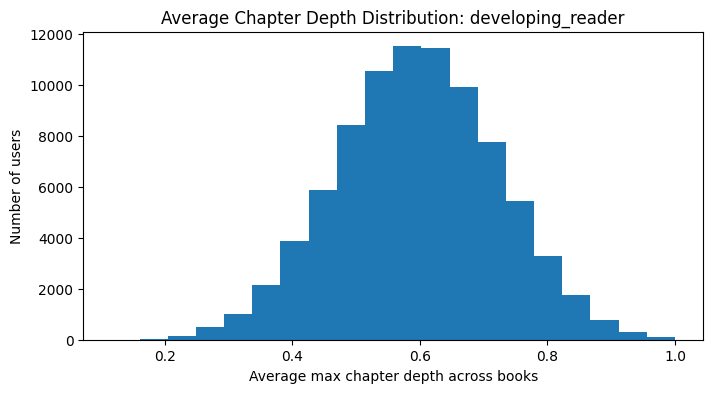

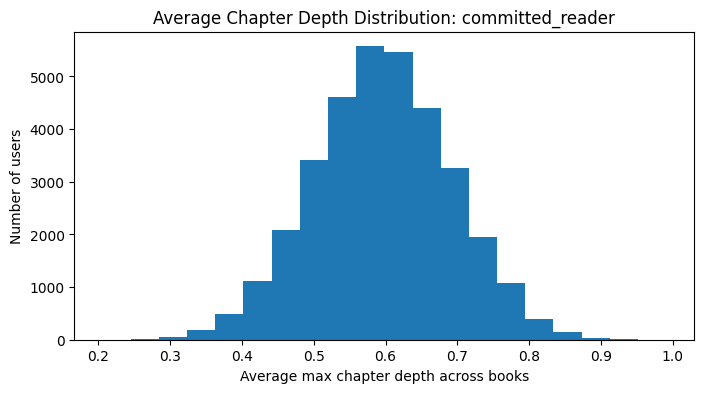

In [19]:
for segment in ["early_reader", "developing_reader", "committed_reader"]:
    values = train_user_activity.loc[
        train_user_activity["activity_segment"] == segment,
        "avg_depth"
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=20)
    plt.title(f"Average Chapter Depth Distribution: {segment}")
    plt.xlabel("Average max chapter depth across books")
    plt.ylabel("Number of users")
    plt.show()

### Depth assumption and decision

`avg_depth` is based on the deepest observed chapter sequence for each user-book pair.

This is worth checking because the prompt mentions chapter order. But in this dataset, depth is not a strong signal:

- most user-book pairs have only one chapter interaction,
- average depth is almost the same across early, developing, and committed readers,
- a late chapter interaction may simply be a random late-chapter touch, not actual completion.

So I keep this section as EDA, but I drop chapter depth from the final scoring logic.

## 10. Train-only taste profiles

In [20]:
train_user_tag_pref = (
    train_interaction_tags
    .groupby(["user_id", "tag"])
    .size()
    .reset_index(name="tag_events")
)

train_user_tag_pref["total_tag_events"] = train_user_tag_pref.groupby("user_id")["tag_events"].transform("sum")
train_user_tag_pref["user_tag_score"] = train_user_tag_pref["tag_events"] / train_user_tag_pref["total_tag_events"]

def normalized_entropy(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[arr > 0]
    if len(arr) <= 1:
        return 0.0
    return float(-(arr * np.log(arr)).sum() / np.log(len(all_tags)))

train_taste_profile = (
    train_user_tag_pref
    .groupby("user_id")
    .agg(
        tag_count=("tag", "nunique"),
        dominant_tag_share=("user_tag_score", "max"),
        tag_entropy=("user_tag_score", normalized_entropy)
    )
    .reset_index()
)

def assign_taste_profile(row):
    if row["dominant_tag_share"] >= 0.30 and row["tag_entropy"] < 0.70:
        return "focused_category"
    if row["tag_entropy"] >= 0.88 and row["tag_count"] >= 10:
        return "broad_explorer"
    return "balanced_taste"

train_user_profile = train_user_activity.merge(train_taste_profile, on="user_id", how="left")

train_user_profile[["tag_count", "dominant_tag_share", "tag_entropy"]] = (
    train_user_profile[["tag_count", "dominant_tag_share", "tag_entropy"]].fillna(0)
)

train_user_profile["taste_profile"] = train_user_profile.apply(assign_taste_profile, axis=1)

display(train_user_profile.head())
display(
    train_user_profile
    .groupby(["activity_segment", "taste_profile"])
    .size()
    .reset_index(name="users")
    .sort_values(["activity_segment", "users"], ascending=[True, False])
)

,user_id,train_total_interactions,train_books_read,train_total_engagement,avg_depth,median_depth,late_depth_book_count,max_depth,activity_segment,tag_count,dominant_tag_share,tag_entropy,taste_profile
0,user_0000013,6,6,4.158883,0.534858,0.549020,3,1.000000,developing_reader,8,0.153846,0.750266,balanced_taste
1,user_0000115,5,5,3.465736,0.552222,0.600000,1,0.800000,developing_reader,9,0.214286,0.777894,balanced_taste
2,user_0000177,5,5,3.465736,0.461558,0.500000,0,0.636364,developing_reader,8,0.300000,0.728569,balanced_taste
3,user_0000188,7,7,4.852030,0.569161,0.500000,2,1.000000,developing_reader,9,0.166667,0.789621,balanced_taste
4,user_0000257,4,4,2.772589,0.630952,0.595238,2,1.000000,developing_reader,9,0.230769,0.774782,balanced_taste


,activity_segment,taste_profile,users
1,committed_reader,broad_explorer,18559
0,committed_reader,balanced_taste,15668
2,committed_reader,focused_category,21
3,developing_reader,balanced_taste,71649
4,developing_reader,broad_explorer,9569
5,developing_reader,focused_category,3671
6,early_reader,balanced_taste,19219
8,early_reader,focused_category,10181
7,early_reader,broad_explorer,11


## 11. Book features and serious-reader quality

In [21]:
book_activity = (
    train_interactions
    .merge(
        chapters[["chapter_id", "book_id", "chapter_sequence_no"]],
        on=["chapter_id", "book_id"],
        how="left"
    )
    .merge(
        book_meta[["book_id", "total_chapters"]],
        on="book_id",
        how="left"
    )
)

book_activity["chapter_depth_ratio"] = book_activity["chapter_sequence_no"] / book_activity["total_chapters"]

book_activity_summary = (
    book_activity
    .groupby("book_id")
    .agg(
        train_total_interactions=("chapter_id", "size"),
        train_unique_users=("user_id", "nunique"),
        avg_interacted_depth=("chapter_depth_ratio", "mean"),
        late_chapter_share=("chapter_depth_ratio", lambda s: float((s >= 0.75).mean()))
    )
    .reset_index()
)

book_activity_summary["popularity_score"] = np.log1p(book_activity_summary["train_unique_users"])
book_activity_summary["popularity_score"] = (
    book_activity_summary["popularity_score"] / book_activity_summary["popularity_score"].max()
)

book_features = (
    book_meta
    .merge(book_activity_summary, on="book_id", how="left")
)

book_features[[
    "train_total_interactions",
    "train_unique_users",
    "avg_interacted_depth",
    "late_chapter_share",
    "popularity_score"
]] = book_features[[
    "train_total_interactions",
    "train_unique_users",
    "avg_interacted_depth",
    "late_chapter_share",
    "popularity_score"
]].fillna(0)

In [22]:
committed_users = train_user_profile.loc[
    train_user_profile["activity_segment"] == "committed_reader",
    "user_id"
]

committed_reader_book_quality = (
    train_user_book[train_user_book["user_id"].isin(committed_users)]
    .groupby("book_id")
    .agg(
        committed_reader_count=("user_id", "nunique"),
        committed_interactions=("interaction_count", "sum")
    )
    .reset_index()
)

# This score captures books that committed readers engage with.
# I intentionally do not include chapter depth here because the depth distribution
# is almost identical across user activity groups and may not represent true completion.
committed_reader_book_quality["serious_quality_raw"] = (
    0.70 * np.log1p(committed_reader_book_quality["committed_reader_count"])
    + 0.30 * np.log1p(committed_reader_book_quality["committed_interactions"])
)

if committed_reader_book_quality["serious_quality_raw"].max() > 0:
    committed_reader_book_quality["serious_quality_score"] = (
        committed_reader_book_quality["serious_quality_raw"]
        / committed_reader_book_quality["serious_quality_raw"].max()
    )
else:
    committed_reader_book_quality["serious_quality_score"] = 0

book_features = book_features.merge(
    committed_reader_book_quality[
        ["book_id", "committed_reader_count", "committed_interactions", "serious_quality_score"]
    ],
    on="book_id",
    how="left"
)

book_features[[
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]] = book_features[[
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]].fillna(0)

display(book_features.head())
display(book_features[[
    "popularity_score",
    "avg_interacted_depth",
    "late_chapter_share",
    "committed_reader_count",
    "committed_interactions",
    "serious_quality_score"
]].describe())

,book_id,total_chapters,author_id,first_published_date,dominant_tag,dominant_tag_share,train_total_interactions,train_unique_users,avg_interacted_depth,late_chapter_share,popularity_score,committed_reader_count,committed_interactions,serious_quality_score
0,100089,3,55121,1995-03-24,Fantasy,0.750000,30,30,0.733333,0.466667,0.498875,13.0,13.0,0.451106
1,100096,1,61876,2015-12-31,Romance,1.000000,16,16,1.000000,1.000000,0.411597,3.0,3.0,0.236966
2,100193,4,67983,1996-01-26,Thriller,0.307692,38,38,0.598684,0.526316,0.532227,13.0,13.0,0.451106
3,100205,4,64099,2016-02-26,Adventure,0.363636,204,204,0.332108,0.107843,0.773304,78.0,78.0,0.746890
4,100301,3,77538,2015-08-14,Humor,0.600000,26,26,0.628205,0.269231,0.478805,9.0,9.0,0.393592


,popularity_score,avg_interacted_depth,late_chapter_share,committed_reader_count,committed_interactions,serious_quality_score
count,9575.000000,9575.000000,9575.000000,9575.000000,9575.000000,9575.000000
mean,0.571075,0.661921,0.448458,33.100574,33.122507,0.508307
std,0.153457,0.162759,0.264826,39.456436,39.510866,0.180375
min,0.159602,0.226589,0.011696,0.000000,0.000000,0.000000
25%,0.467625,0.563908,0.283019,9.000000,9.000000,0.393592
50%,0.542993,0.633721,0.395833,16.000000,16.000000,0.484294
75%,0.694898,0.733333,0.548003,45.000000,45.000000,0.654448
max,1.000000,1.000000,1.000000,346.000000,347.000000,1.000000


### High-confidence candidate pool

One thing I had to control for: a hybrid recommender can become too broad if it is allowed to pull from the full catalog.

The catalog has 9,575 books. Popularity baseline recommends almost the same 10–12 books to everyone, which is too narrow. But an unconstrained hybrid can swing too far the other way and recommend most of the catalog across users.

So I keep a **high-confidence recommendation pool** of 2,500 books, based on popularity and committed-reader quality. That is about 26% of the catalog — wide enough for discovery, but not so wide that the system sprays random books.

In [23]:
# High-confidence recommendation pool.
# This keeps the hybrid model from recommending from almost the entire catalog.

book_features["candidate_pool_score"] = (
    0.55 * book_features["popularity_score"]
    + 0.45 * book_features["serious_quality_score"]
)

ELIGIBLE_CATALOG_SIZE = 2500

eligible_books = set(
    book_features
    .sort_values("candidate_pool_score", ascending=False)
    .head(ELIGIBLE_CATALOG_SIZE)["book_id"]
)

print("Eligible recommendation pool size:", len(eligible_books))
print("Eligible catalog share:", len(eligible_books) / book_features["book_id"].nunique())

Eligible recommendation pool size: 2500
Eligible catalog share: 0.26109660574412535


### Committed-reader quality

`serious_quality_score` captures books that committed readers interact with.

I use committed readers as a quality signal because they have more history than early readers. But I avoid using chapter depth here because the depth distribution did not meaningfully separate user types.

So this score is based on:

- number of committed readers who interacted with a book,
- total committed-reader interactions for the book.

This gives me a stronger signal than raw global popularity, without pretending that depth equals completion.

## 12. Category-trending books

In [24]:
book_tag_features = book_tag_profile_df.merge(
    book_features[["book_id", "popularity_score", "serious_quality_score"]],
    on="book_id",
    how="left"
)

book_tag_features[["popularity_score", "serious_quality_score"]] = (
    book_tag_features[["popularity_score", "serious_quality_score"]].fillna(0)
)

book_tag_features["category_trending_score"] = (
    book_tag_features["book_tag_score"]
    * (
        0.60 * book_tag_features["popularity_score"]
        + 0.40 * book_tag_features["serious_quality_score"]
    )
)

category_top_books = {
    tag: df.sort_values("category_trending_score", ascending=False)["book_id"].head(300).tolist()
    for tag, df in book_tag_features.groupby("tag")
}

top_category_examples = (
    book_tag_features
    .sort_values(["tag", "category_trending_score"], ascending=[True, False])
    .groupby("tag")
    .head(3)
)

display(top_category_examples.head(30))

,book_id,tag,tag_count,total_tag_count,book_tag_score,popularity_score,serious_quality_score,category_trending_score
32837,567636,Adventure,3,3,1.000000,0.766782,0.728640,0.751525
63053,995528,Adventure,2,2,1.000000,0.736389,0.684992,0.715830
19287,372935,Adventure,4,6,0.666667,0.756016,0.716157,0.493382
25996,473024,Crime,1,1,1.000000,0.759174,0.718728,0.742996
31695,551538,Crime,4,5,0.800000,0.772594,0.735714,0.606273
18910,367352,Crime,8,11,0.727273,0.789388,0.761402,0.565959
56373,898557,Dystopian,4,5,0.800000,0.757604,0.705470,0.589400
54241,869832,Dystopian,3,4,0.750000,0.755215,0.702691,0.550654
38462,646174,Dystopian,10,17,0.588235,0.801552,0.793887,0.469698
13388,288006,Fantasy,1,1,1.000000,0.755215,0.738008,0.748333


## 13. Collaborative similarity

In [25]:
user_ids = train_user_book["user_id"].unique()
book_ids = book_features["book_id"].unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
book_to_idx = {b: i for i, b in enumerate(book_ids)}
idx_to_book = {i: b for b, i in book_to_idx.items()}

matrix_rows = train_user_book["user_id"].map(user_to_idx).to_numpy()
matrix_cols = train_user_book["book_id"].map(book_to_idx).to_numpy()
matrix_values = train_user_book["engagement_weight"].to_numpy()

user_book_matrix = csr_matrix(
    (matrix_values, (matrix_rows, matrix_cols)),
    shape=(len(user_ids), len(book_ids))
)

book_user_matrix = user_book_matrix.T

print("user_book_matrix:", user_book_matrix.shape)
print("non-zero entries:", user_book_matrix.nnz)

user_book_matrix: (148548, 9575)
non-zero entries: 849717


In [26]:
book_similarity = cosine_similarity(book_user_matrix, dense_output=False)

TOP_SIMILAR_PER_BOOK = 80
similar_books = {}

for book_idx in range(book_similarity.shape[0]):
    row = book_similarity.getrow(book_idx)

    if row.nnz == 0:
        similar_books[idx_to_book[book_idx]] = []
        continue

    indices = row.indices
    values = row.data

    keep = indices != book_idx
    indices = indices[keep]
    values = values[keep]

    if len(values) > TOP_SIMILAR_PER_BOOK:
        top_pos = np.argpartition(values, -TOP_SIMILAR_PER_BOOK)[-TOP_SIMILAR_PER_BOOK:]
        indices = indices[top_pos]
        values = values[top_pos]

    order = np.argsort(values)[::-1]

    similar_books[idx_to_book[book_idx]] = [
        (idx_to_book[int(indices[i])], float(values[i]))
        for i in order
    ]

example_book = next(iter(similar_books))
print("Example book:", example_book)
print("Similar books:", similar_books[example_book][:5])

Example book: 100089
Similar books: [(np.int64(881782), 0.043033148291193535), (np.int64(112394), 0.043033148291193535), (np.int64(489439), 0.03726779962499652), (np.int64(964996), 0.036514837167011094), (np.int64(407645), 0.03580574370197166)]


## 14. Lookups and segment weights

In [27]:
user_history_books = train_user_book.groupby("user_id")["book_id"].apply(set).to_dict()

user_history_weighted = {
    user_id: list(group[["book_id", "engagement_weight"]].itertuples(index=False, name=None))
    for user_id, group in train_user_book.groupby("user_id")
}

user_tag_lookup = {
    user_id: dict(zip(group["tag"], group["user_tag_score"]))
    for user_id, group in train_user_tag_pref.groupby("user_id")
}

book_tag_lookup = {
    book_id: dict(zip(group["tag"], group["book_tag_score"]))
    for book_id, group in book_tag_profile_df.groupby("book_id")
}

train_user_author_pref = (
    train_user_book
    .groupby(["user_id", "author_id"], as_index=False)["engagement_weight"]
    .sum()
    .rename(columns={"engagement_weight": "author_weight"})
)

train_user_author_pref["total_author_weight"] = train_user_author_pref.groupby("user_id")["author_weight"].transform("sum")
train_user_author_pref["author_score"] = (
    train_user_author_pref["author_weight"] / train_user_author_pref["total_author_weight"]
)

user_author_lookup = {
    user_id: dict(zip(group["author_id"], group["author_score"]))
    for user_id, group in train_user_author_pref.groupby("user_id")
}

user_activity_lookup = train_user_profile.set_index("user_id")["activity_segment"].to_dict()
user_taste_lookup = train_user_profile.set_index("user_id")["taste_profile"].to_dict()

book_lookup = book_features.set_index("book_id").to_dict("index")

popular_books = book_features.sort_values("popularity_score", ascending=False)["book_id"].tolist()
serious_quality_books = book_features.sort_values("serious_quality_score", ascending=False)["book_id"].tolist()

In [28]:
SEGMENT_WEIGHTS = {
    "early_reader": {
        "collab": 0.10,
        "genre": 0.20,
        "author": 0.03,
        "popularity": 0.55,
        "serious_quality": 0.12
    },
    "developing_reader": {
        "collab": 0.25,
        "genre": 0.30,
        "author": 0.05,
        "popularity": 0.25,
        "serious_quality": 0.15
    },
    "committed_reader": {
        "collab": 0.32,
        "genre": 0.24,
        "author": 0.14,
        "popularity": 0.10,
        "serious_quality": 0.20
    }
}

display(pd.DataFrame(SEGMENT_WEIGHTS).T)

,collab,genre,author,popularity,serious_quality
early_reader,0.10,0.20,0.03,0.55,0.12
developing_reader,0.25,0.30,0.05,0.25,0.15
committed_reader,0.32,0.24,0.14,0.10,0.20


## 15. Candidate generation and scoring

In [29]:
def generate_candidates(user_id, n_popular=150, n_category=50, n_similar=30, n_serious=50, max_candidates=250):
    seen = user_history_books.get(user_id, set())
    activity_segment = user_activity_lookup.get(user_id, "early_reader")

    candidates = {}

    def add_candidate(candidate_book, score=0.0):
        if candidate_book in seen:
            return
        if candidate_book not in eligible_books:
            return
        candidates[candidate_book] = max(candidates.get(candidate_book, 0.0), score)

    # Similar-book candidates from user history.
    # Restricted to the eligible pool so the model does not spray the full catalog.
    for source_book, source_weight in user_history_weighted.get(user_id, []):
        for candidate_book, sim_score in similar_books.get(source_book, [])[:n_similar]:
            add_candidate(candidate_book, sim_score * source_weight)

    # Category candidates from the user's top interacted tags.
    user_tags = user_tag_lookup.get(user_id, {})
    top_tags = sorted(user_tags.items(), key=lambda x: x[1], reverse=True)[:2]

    for tag, tag_weight in top_tags:
        for candidate_book in category_top_books.get(tag, [])[:n_category]:
            add_candidate(candidate_book, 0.0)

    # Committed-reader quality candidates for developing and committed readers.
    if activity_segment in {"developing_reader", "committed_reader"}:
        for candidate_book in serious_quality_books[:n_serious]:
            add_candidate(candidate_book, 0.0)

    # Popular fallback for everyone.
    for candidate_book in popular_books[:n_popular]:
        add_candidate(candidate_book, 0.0)

    return sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:max_candidates]

In [30]:
def score_candidates(user_id, candidates):
    activity_segment = user_activity_lookup.get(user_id, "early_reader")
    weights = SEGMENT_WEIGHTS[activity_segment]

    tag_pref = user_tag_lookup.get(user_id, {})
    author_pref = user_author_lookup.get(user_id, {})

    max_collab = max([score for _, score in candidates], default=0.0)
    rows = []

    for book_id, raw_collab in candidates:
        if book_id not in book_lookup:
            continue

        meta = book_lookup[book_id]
        book_tags = book_tag_lookup.get(book_id, {})

        collaborative_score = raw_collab / max_collab if max_collab > 0 else 0.0
        genre_score = sum(tag_pref.get(tag, 0.0) * book_weight for tag, book_weight in book_tags.items())
        author_score = author_pref.get(meta["author_id"], 0.0)
        popularity_score = meta.get("popularity_score", 0.0)
        serious_quality_score = meta.get("serious_quality_score", 0.0)

        final_score = (
            weights["collab"] * collaborative_score
            + weights["genre"] * genre_score
            + weights["author"] * author_score
            + weights["popularity"] * popularity_score
            + weights["serious_quality"] * serious_quality_score
        )

        rows.append({
            "book_id": book_id,
            "final_score": final_score,
            "activity_segment": activity_segment,
            "taste_profile": user_taste_lookup.get(user_id, "unknown"),
            "dominant_tag": meta.get("dominant_tag"),
            "collaborative_score": collaborative_score,
            "genre_score": genre_score,
            "author_score": author_score,
            "popularity_score": popularity_score,
            "serious_quality_score": serious_quality_score,
            "author_id": meta["author_id"]
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("final_score", ascending=False)


def explain_recommendation(row):
    activity_segment = row["activity_segment"]

    if row["author_score"] >= 0.12:
        return "author_affinity", "same author signal from user's reading history"

    if row["collaborative_score"] >= 0.60 and row["genre_score"] >= 0.08:
        return "similar_reader_category_match", "similar-reader signal with category overlap"

    if row["collaborative_score"] >= 0.60:
        return "similar_reader_match", "readers/books with similar histories point here"

    if row["genre_score"] >= 0.12:
        return "category_match", "matches user's interacted chapter tags"

    if row["serious_quality_score"] >= 0.75 and activity_segment in {"developing_reader", "committed_reader"}:
        return "committed_reader_quality", "strong signal from committed readers"

    if activity_segment == "early_reader":
        return "popular_category_safe_pick", "safe popularity/category pick for limited history"

    if row["popularity_score"] >= 0.80:
        return "popular_safe_pick", "high-popularity fallback"

    return "explore_new_book", "balanced candidate from multiple weak signals"


def diversify_recommendations(scored, top_k=10, max_per_tag=3):
    if scored.empty:
        return scored

    selected = []
    tag_counts = defaultdict(int)

    for _, row in scored.iterrows():
        tag = row["dominant_tag"]
        if tag_counts[tag] < max_per_tag:
            selected.append(row)
            tag_counts[tag] += 1
        if len(selected) == top_k:
            break

    if len(selected) < top_k:
        selected_ids = {row["book_id"] for row in selected}
        for _, row in scored.iterrows():
            if row["book_id"] not in selected_ids:
                selected.append(row)
            if len(selected) == top_k:
                break

    return pd.DataFrame(selected)


def recommend_books(user_id, top_k=10, diversify=True):
    candidates = generate_candidates(user_id)
    scored = score_candidates(user_id, candidates)

    if scored.empty:
        return scored

    if diversify:
        output = diversify_recommendations(scored, top_k=top_k, max_per_tag=3)
    else:
        output = scored.head(top_k)

    output = output.copy()
    labels = output.apply(explain_recommendation, axis=1)
    output["recommendation_type"] = [x[0] for x in labels]
    output["recommendation_reason"] = [x[1] for x in labels]

    cols = [
        "book_id",
        "final_score",
        "recommendation_type",
        "recommendation_reason",
        "activity_segment",
        "taste_profile",
        "dominant_tag",
        "collaborative_score",
        "genre_score",
        "author_score",
        "popularity_score",
        "serious_quality_score",
        "author_id"
    ]

    return output[cols].reset_index(drop=True)

## 16. Sample recommendations

In [31]:
sample_users = list(test_user_book["user_id"].drop_duplicates().head(5))

for user_id in sample_users:
    print("=" * 100)
    print("User:", user_id)

    print("\nReader profile from training history:")
    display(train_user_profile[train_user_profile["user_id"] == user_id][[
        "user_id",
        "train_total_interactions",
        "train_books_read",
        "avg_depth",
        "late_depth_book_count",
        "tag_count",
        "dominant_tag_share",
        "tag_entropy",
        "activity_segment",
        "taste_profile"
    ]])

    print("\nKnown training history:")
    display(train_user_book[train_user_book["user_id"] == user_id][[
        "book_id",
        "interaction_count",
        "max_chapter_depth",
        "coverage_ratio",
        "author_id"
    ]].head(10))

    print("\nRecommendations:")
    display(recommend_books(user_id, top_k=10, diversify=True))

User: user_0000013

Reader profile from training history:


,user_id,train_total_interactions,train_books_read,avg_depth,late_depth_book_count,tag_count,dominant_tag_share,tag_entropy,activity_segment,taste_profile
0,user_0000013,6,6,0.534858,3,8,0.153846,0.750266,developing_reader,balanced_taste



Known training history:


,book_id,interaction_count,max_chapter_depth,coverage_ratio,author_id
1,461083,1,0.125000,0.125000,34356
2,469844,1,1.000000,0.500000,52899
3,635456,1,0.875000,0.125000,46822
4,878246,1,0.111111,0.111111,22675
5,964446,1,0.764706,0.058824,93507
6,976042,1,0.333333,0.333333,53449



Recommendations:


...

,user_id,train_total_interactions,train_books_read,avg_depth,late_depth_book_count,tag_count,dominant_tag_share,tag_entropy,activity_segment,taste_profile
77859,user_5241636,3,3,0.325397,0,5,0.222222,0.583849,early_reader,balanced_taste



Known training history:


,book_id,interaction_count,max_chapter_depth,coverage_ratio,author_id
524291,234097,1,0.333333,0.166667,21015
524292,409499,1,0.500000,0.166667,73483
524294,923824,1,0.142857,0.142857,96643



Recommendations:


,book_id,final_score,recommendation_type,recommendation_reason,activity_segment,taste_profile,dominant_tag,collaborative_score,genre_score,author_score,popularity_score,serious_quality_score,author_id
0,343697,0.705370,similar_reader_category_match,similar-reader signal with category overlap,early_reader,balanced_taste,Historical Fiction,0.914563,0.156863,0.0,0.870051,0.866773,67240
1,672233,0.680923,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Graphic Novel,0.000000,0.054614,0.0,1.000000,1.000000,98470
2,615276,0.663502,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Mystery,0.000000,0.054422,0.0,0.974699,0.971113,15513
3,899484,0.656418,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Literary Fiction,0.000000,0.115079,0.0,0.942945,0.956520,47051
4,760434,0.655473,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Mystery,0.000000,0.023810,0.0,0.970018,0.976675,20357
5,756944,0.654482,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Young Adult,0.000000,0.031250,0.0,0.966687,0.971287,36794
6,395485,0.654196,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Horror,0.000000,0.058480,0.0,0.958801,0.959665,62802
7,551601,0.651043,category_match,matches user's interacted chapter tags,early_reader,balanced_taste,Historical Fiction,0.000000,0.122222,0.0,0.938921,0.918266,18300
8,682667,0.650123,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Dystopian,0.000000,0.081633,0.0,0.944261,0.953769,28388
9,986925,0.648903,popular_category_safe_pick,safe popularity/category pick for limited history,early_reader,balanced_taste,Literary Fiction,0.000000,0.118056,0.0,0.934082,0.929556,19744


## Evaluation

I evaluate the model with ranking metrics:

| Metric | Why it matters |
|---|---|
| Recall@10 / Hit Rate@10 | Did the held-out book appear anywhere in the top 10? |
| NDCG@10 | Did the model rank the held-out book closer to the top? |
| Catalog coverage | Is the model recommending a meaningful part of the catalog, or the same few books? |
| Tag diversity@10 | Is the top-10 list too narrow by category? |

I also compare against a simple popularity baseline. This is important because in sparse implicit-feedback data, popularity is often surprisingly strong. Without this baseline, the model numbers are hard to interpret.


In [32]:
def recall_at_k(recs, target, k):
    return int(target in recs[:k])

def ndcg_at_k(recs, target, k):
    top = recs[:k]
    if target not in top:
        return 0.0
    rank = top.index(target) + 1
    return float(1.0 / np.log2(rank + 1))

def list_tag_diversity(recs):
    tags = []
    for book_id in recs:
        meta = book_lookup.get(book_id)
        if meta is not None:
            tags.append(meta.get("dominant_tag"))
    return len(set(tags))

def recommend_popular_books(user_id, top_k=10):
    seen = user_history_books.get(user_id, set())
    recs = [book_id for book_id in popular_books if book_id not in seen]
    return recs[:top_k]

def evaluate_segmented_model(test_df, sample_size=5000, top_k=10):
    if len(test_df) > sample_size:
        eval_df = test_df.sample(sample_size, random_state=RANDOM_SEED)
    else:
        eval_df = test_df.copy()

    rows = []
    all_model_recs = []
    all_pop_recs = []

    for user_id, target_book in eval_df[["user_id", "book_id"]].itertuples(index=False):
        model_df = recommend_books(user_id, top_k=top_k, diversify=True)
        model_recs = model_df["book_id"].tolist() if not model_df.empty else []

        pop_recs = recommend_popular_books(user_id, top_k=top_k)

        all_model_recs.extend(model_recs)
        all_pop_recs.extend(pop_recs)

        rows.append({
            "user_id": user_id,
            "target_book": target_book,
            "activity_segment": user_activity_lookup.get(user_id, "unknown"),
            "model_recall@5": recall_at_k(model_recs, target_book, 5),
            "model_recall@10": recall_at_k(model_recs, target_book, 10),
            "model_ndcg@5": ndcg_at_k(model_recs, target_book, 5),
            "model_ndcg@10": ndcg_at_k(model_recs, target_book, 10),
            "model_tag_diversity@10": list_tag_diversity(model_recs),
            "pop_recall@5": recall_at_k(pop_recs, target_book, 5),
            "pop_recall@10": recall_at_k(pop_recs, target_book, 10),
            "pop_ndcg@5": ndcg_at_k(pop_recs, target_book, 5),
            "pop_ndcg@10": ndcg_at_k(pop_recs, target_book, 10),
            "pop_tag_diversity@10": list_tag_diversity(pop_recs),
        })

    result_df = pd.DataFrame(rows)

    summary = pd.Series({
        "evaluated_users": len(result_df),
        "model_recall@5": result_df["model_recall@5"].mean(),
        "model_recall@10": result_df["model_recall@10"].mean(),
        "model_ndcg@5": result_df["model_ndcg@5"].mean(),
        "model_ndcg@10": result_df["model_ndcg@10"].mean(),
        "model_catalog_coverage": len(set(all_model_recs)) / book_features["book_id"].nunique(),
        "model_unique_recommended_books": len(set(all_model_recs)),
        "model_avg_tag_diversity@10": result_df["model_tag_diversity@10"].mean(),
        "pop_recall@5": result_df["pop_recall@5"].mean(),
        "pop_recall@10": result_df["pop_recall@10"].mean(),
        "pop_ndcg@5": result_df["pop_ndcg@5"].mean(),
        "pop_ndcg@10": result_df["pop_ndcg@10"].mean(),
        "pop_catalog_coverage": len(set(all_pop_recs)) / book_features["book_id"].nunique(),
        "pop_unique_recommended_books": len(set(all_pop_recs)),
        "pop_avg_tag_diversity@10": result_df["pop_tag_diversity@10"].mean(),
    })

    return result_df, summary

In [36]:
eval_results, eval_summary = evaluate_segmented_model(
    test_user_book,
    sample_size=5000,
    top_k=10
)

summary_table = pd.DataFrame({
    "segmented_hybrid": eval_summary[[
        "model_recall@5",
        "model_recall@10",
        "model_ndcg@5",
        "model_ndcg@10",
        "model_catalog_coverage",
        "model_unique_recommended_books",
        "model_avg_tag_diversity@10"
    ]].rename(lambda x: x.replace("model_", "")),
    "popularity_baseline": eval_summary[[
        "pop_recall@5",
        "pop_recall@10",
        "pop_ndcg@5",
        "pop_ndcg@10",
        "pop_catalog_coverage",
        "pop_unique_recommended_books",
        "pop_avg_tag_diversity@10"
    ]].rename(lambda x: x.replace("pop_", ""))
})

display(eval_summary)
display(summary_table)

results_for_writeup = pd.DataFrame([
    {
        "model": "Popularity baseline",
        "Recall@10 / HR@10": eval_summary["pop_recall@10"],
        "NDCG@10": eval_summary["pop_ndcg@10"],
        "Catalog coverage": eval_summary["pop_catalog_coverage"],
        "Unique recommended books": eval_summary["pop_unique_recommended_books"],
        "Notes": "Strong recall baseline, but nearly same shelf for most users"
    },
    {
        "model": "Segmented hybrid",
        "Recall@10 / HR@10": eval_summary["model_recall@10"],
        "NDCG@10": eval_summary["model_ndcg@10"],
        "Catalog coverage": eval_summary["model_catalog_coverage"],
        "Unique recommended books": eval_summary["model_unique_recommended_books"],
        "Notes": "Lower recall, higher coverage/diversity, segment-aware"
    }
])

display(results_for_writeup)


evaluated_users                   5000.000000
model_recall@5                       0.001800
model_recall@10                      0.004400
model_ndcg@5                         0.001093
model_ndcg@10                        0.001879
model_catalog_coverage               0.225170
model_unique_recommended_books    2156.000000
model_avg_tag_diversity@10           6.818400
pop_recall@5                         0.003200
pop_recall@10                        0.006400
pop_ndcg@5                           0.001998
pop_ndcg@10                          0.002977
pop_catalog_coverage                 0.001253
pop_unique_recommended_books        12.000000
pop_avg_tag_diversity@10             6.034600
dtype: float64

,segmented_hybrid,popularity_baseline
recall@5,0.001800,0.003200
recall@10,0.004400,0.006400
ndcg@5,0.001093,0.001998
ndcg@10,0.001879,0.002977
catalog_coverage,0.225170,0.001253
unique_recommended_books,2156.000000,12.000000
avg_tag_diversity@10,6.818400,6.034600


,model,Recall@10 / HR@10,NDCG@10,Catalog coverage,Unique recommended books,Notes
0,Popularity baseline,0.0064,0.002977,0.001253,12.0,"Strong recall baseline, but nearly same shelf ..."
1,Segmented hybrid,0.0044,0.001879,0.225170,2156.0,"Lower recall, higher coverage/diversity, segme..."


### How I read these results

The popularity baseline is expected to be strong on random holdout recall: globally popular books are more likely to appear somewhere in many users' histories.

But the popularity baseline is also very concentrated. It recommends almost the same tiny set of books to most users. That makes it a useful baseline and fallback, but not a good personalized discovery experience by itself.

The segmented hybrid is intentionally a product tradeoff: it gives up some random-holdout recall to improve catalog coverage, tag diversity, and segment-aware behavior.


## 18. Popularity baseline concentration check

The popularity baseline looks decent on Recall@K, but it is extremely concentrated.

That is because popularity here is relative. The most popular book is still read by less than 1% of users, but it is the most interacted book compared to the rest of the catalog. Since most users have not seen the global top books, the baseline gives almost everyone the same top 10.

This table shows how often each baseline book gets recommended in the 5,000-user evaluation sample.

In [37]:
pop_baseline_books = []

eval_df_for_pop_check = test_user_book.sample(5000, random_state=RANDOM_SEED)

for user_id in eval_df_for_pop_check["user_id"]:
    pop_baseline_books.extend(recommend_popular_books(user_id, top_k=10))

pop_baseline_frequency = (
    pd.Series(pop_baseline_books)
    .value_counts()
    .reset_index()
)

pop_baseline_frequency.columns = ["book_id", "times_recommended"]

pop_baseline_frequency = pop_baseline_frequency.merge(
    book_features[[
        "book_id",
        "train_unique_users",
        "train_total_interactions",
        "popularity_score",
        "dominant_tag",
        "author_id",
        "total_chapters"
    ]],
    on="book_id",
    how="left"
)

display(pop_baseline_frequency)

,book_id,times_recommended,train_unique_users,train_total_interactions,popularity_score,dominant_tag,author_id,total_chapters
0,478798,4982,672,674,0.945999,Horror,17152,19
1,791274,4980,698,702,0.951505,Mystery,51467,19
2,316800,4980,676,679,0.946859,Humor,27647,20
3,395485,4979,734,736,0.958801,Horror,62802,8
4,672233,4978,975,977,1.000000,Graphic Novel,98470,20
5,137728,4977,669,671,0.945349,Fantasy,10726,18
6,615276,4971,819,821,0.974699,Mystery,15513,19
7,181288,4971,683,684,0.948354,Young Adult,55056,20
8,756944,4970,775,777,0.966687,Young Adult,36794,16
9,760434,4967,793,793,0.970018,Mystery,20357,16


## 19. Evaluation by activity segment

In [38]:
segment_eval = (
    eval_results
    .groupby("activity_segment")
    .agg(
        users=("user_id", "count"),
        model_recall_at_10=("model_recall@10", "mean"),
        model_ndcg_at_10=("model_ndcg@10", "mean"),
        model_tag_diversity_at_10=("model_tag_diversity@10", "mean"),
        pop_recall_at_10=("pop_recall@10", "mean"),
        pop_ndcg_at_10=("pop_ndcg@10", "mean"),
        pop_tag_diversity_at_10=("pop_tag_diversity@10", "mean")
    )
    .reindex(["early_reader", "developing_reader", "committed_reader"])
    .reset_index()
)

display(segment_eval)

,activity_segment,users,model_recall_at_10,model_ndcg_at_10,model_tag_diversity_at_10,pop_recall_at_10,pop_ndcg_at_10,pop_tag_diversity_at_10
0,early_reader,980,0.002041,0.001315,6.129592,0.004082,0.002117,6.018367
1,developing_reader,2871,0.004876,0.001929,6.877743,0.006618,0.002777,6.030651
2,committed_reader,1149,0.005222,0.002234,7.257615,0.007833,0.004210,6.058312


## 20. Recommendation reason checks

In [39]:
reason_users = test_user_book["user_id"].drop_duplicates().sample(1000, random_state=RANDOM_SEED)

reason_rows = []

for user_id in reason_users:
    rec_df = recommend_books(user_id, top_k=10, diversify=True)
    if rec_df.empty:
        continue
    reason_rows.append(rec_df[[
        "activity_segment",
        "taste_profile",
        "recommendation_type",
        "dominant_tag",
        "book_id"
    ]])

reason_sample = pd.concat(reason_rows, ignore_index=True)

reason_summary = (
    reason_sample
    .groupby(["activity_segment", "recommendation_type"])
    .size()
    .reset_index(name="recommendations")
    .sort_values(["activity_segment", "recommendations"], ascending=[True, False])
)

display(reason_summary)

tag_mix = (
    reason_sample
    .groupby(["activity_segment", "dominant_tag"])
    .size()
    .reset_index(name="recommended_books")
    .sort_values(["activity_segment", "recommended_books"], ascending=[True, False])
)

display(tag_mix.groupby("activity_segment").head(5))

,activity_segment,recommendation_type,recommendations
5,committed_reader,similar_reader_match,1091
2,committed_reader,committed_reader_quality,613
4,committed_reader,similar_reader_category_match,341
3,committed_reader,explore_new_book,179
1,committed_reader,category_match,42
0,committed_reader,author_affinity,4
8,developing_reader,committed_reader_quality,2451
12,developing_reader,similar_reader_match,1838
11,developing_reader,similar_reader_category_match,741
7,developing_reader,category_match,493


,activity_segment,dominant_tag,recommended_books
9,committed_reader,Mystery,270
4,committed_reader,Graphic Novel,256
14,committed_reader,Young Adult,200
7,committed_reader,Humor,161
2,committed_reader,Dystopian,156
24,developing_reader,Mystery,891
19,developing_reader,Graphic Novel,678
29,developing_reader,Young Adult,652
21,developing_reader,Horror,427
22,developing_reader,Humor,341


## Results interpretation

The final model is intentionally not trying to beat popularity on random holdout recall at any cost.

The popularity baseline gets better Recall@10 because the held-out book is random, and popular books have a higher chance of appearing somewhere in many users' histories. But the baseline recommends almost the same small set of books to most users. In the sampled evaluation, it recommended only a tiny fraction of the catalog.

The segmented hybrid has lower Recall@10, but much better catalog coverage and tag diversity. That is the product tradeoff I am choosing: not the same global shelf for everyone, but also not an unconstrained catalog spray.

The model behavior by user segment is the important part:

- early readers get safer popularity/category recommendations,
- developing readers get a mix of category, similar-reader, and committed-reader quality signals,
- committed readers get more similar-reader, author, and committed-reader quality signals.

One key caveat: global popularity is not meaningless, but it is blunt. Even the most popular book is seen by a small share of users because the catalog is sparse and wide. So popularity is useful as a prior, especially for low-history users, but not enough as the full recommender.


## Tradeoffs and what I would improve next

### Tradeoffs made

| Choice | Alternative | Why I chose this |
|---|---|---|
| Book-level recommendation | Next-chapter recommendation | Almost no user-book pairs contain more than one chapter interaction |
| Segmented hybrid | One global model for all users | Low-history and high-history users should not be personalized with the same confidence |
| Popularity as fallback/prior | Pure popularity recommender | Popularity is useful but too concentrated on the same few books |
| Tags as lightweight signals | Heavy content-based genre model | Genre distribution is fairly uniform, so tags should nudge rather than dominate |
| Random leave-one-out | Temporal split | No timestamps are available |

### Offline guardrails against bad recommender behavior

Even though this is an offline notebook, I still added a few checks against obvious recommender failure modes:

- compare against popularity to expose popularity bias,
- track catalog coverage so the model does not collapse into the same tiny shelf,
- track tag diversity so the top-10 list does not become too narrow,
- restrict recommendations to a high-confidence catalog pool to avoid spraying most of the catalog,
- use activity segmentation so low-history users do not get fake over-personalization.

### What I would improve with more time

1. **Benchmark ALS or BPR.** I would compare this segmented hybrid against implicit-feedback models like ALS or BPR. I chose not to use them as the primary model here because the current goal was to keep the system interpretable and tightly connected to the data constraints.
2. **Use timestamps if available.** Timestamps would unlock chronological train/test splits, recency weighting, trending content, and true session/sequential models.
3. **Add a separate continue-reading module.** This only makes sense if richer progression/session data exists.
4. **Tune segment weights with validation or online metrics.** The current weights are designed from product logic; with more time I would tune them more systematically.
5. **Use author features more deeply.** Author affinity is sparse but useful; a stronger hybrid could model author clusters or repeat-author behavior.

I would not immediately jump to a deep sequence model on this dataset. The data does not contain enough sequential signal to justify it.


## Final summary

This solution builds a segmented, book-level recommender for sparse implicit-feedback data.

The system first asks: **how much user history do I actually have?**

- `early_reader`: 1–3 interactions
- `developing_reader`: 4–7 interactions
- `committed_reader`: 8+ interactions

Then it changes the recommendation strategy by segment.

The final recommender combines:

- popularity as a fallback/prior,
- user tag affinity as a lightweight category signal,
- author affinity where available,
- collaborative item similarity,
- committed-reader quality,
- and a high-confidence candidate pool to avoid recommending too broadly.

Chapter depth is inspected but not used in the final score, because the data does not support it strongly enough.

The main point is not that this is the most complex recommender. It is that the model is scoped to what the data can actually support: next-book discovery, not next-chapter prediction.
